# Inferência - RetinaNet

Notebook dedicado exclusivamente à inferência do modelo treinado em imagens de teste e em imagens externas.

In [1]:
from pcb_utils import install_dependencies

install_dependencies({
    "torch": "torch",
    "torchvision": "torchvision",
    "Pillow": "PIL",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "tqdm": "tqdm",
})

Todas as dependências já estão instaladas.


In [2]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from tqdm.auto import tqdm

import torch
from torchvision.transforms import functional as F
from torchvision.models.detection import retinanet_resnet50_fpn
from IPython.display import display

from pcb_utils import (
    detect_device,
    find_latest_checkpoint_pytorch,
    select_test_images,
    load_image_tensor,
    draw_predictions,
    display_image_grid,
    export_predictions_csv,
    export_class_summary,
)

/home/alexandre-oliveira/Projetos/pcb-defect-detection/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
PROJECT_ROOT = Path.cwd()
DATASET_ROOT = PROJECT_ROOT / "pcb-defect-dataset-3800-coco"
TEST_IMAGES_DIR = DATASET_ROOT / "test"

RUNS_DIR = PROJECT_ROOT / "runs" / "detect" / "tcc_pcb_defect_detection" / "retinanet_resnet50_fpn"
EVAL_OUT_DIR = PROJECT_ROOT / "runs" / "detect" / "eval_results" / "retinanet"
EVAL_OUT_DIR.mkdir(parents=True, exist_ok=True)

if not TEST_IMAGES_DIR.exists():
    raise FileNotFoundError(f"Diretório de teste não encontrado: {TEST_IMAGES_DIR}")

if not RUNS_DIR.exists():
    raise FileNotFoundError(f"Diretório de runs não encontrado: {RUNS_DIR}")

RUN_DIR, CHECKPOINT_PATH, CLASS_MAP_PATH = find_latest_checkpoint_pytorch(RUNS_DIR)
DEVICE, _ = detect_device()
DEVICE = torch.device(DEVICE) if isinstance(DEVICE, str) else torch.device(f"cuda:{DEVICE}")

print(f"Run selecionado: {RUN_DIR}")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Class map: {CLASS_MAP_PATH}")
print(f"Dispositivo de inferência: {DEVICE}")

Dispositivo detectado: CUDA (NVIDIA GeForce GTX 1060 6GB)
Run selecionado: /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/tcc_pcb_defect_detection/retinanet_resnet50_fpn/20260430_0910_retinanet_resnet50_fpn_e50_bs4_seed42_baseline
Checkpoint: /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/tcc_pcb_defect_detection/retinanet_resnet50_fpn/20260430_0910_retinanet_resnet50_fpn_e50_bs4_seed42_baseline/best_model.pth
Class map: /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/tcc_pcb_defect_detection/retinanet_resnet50_fpn/20260430_0910_retinanet_resnet50_fpn_e50_bs4_seed42_baseline/class_map.json
Dispositivo de inferência: cuda:0


In [4]:
with open(CLASS_MAP_PATH, "r", encoding="utf-8") as f:
    class_map_data = json.load(f)

label_to_name = {int(k): v for k, v in class_map_data["label_to_name"].items()}
num_classes = max(label_to_name.keys()) + 1  # inclui background

model = retinanet_resnet50_fpn(weights=None, num_classes=num_classes)

checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu")
model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()

default_score_threshold = float(checkpoint.get("config", {}).get("score_threshold", 0.30))
print(f"Modelo carregado com {num_classes} classes totais.")
print(f"Score threshold padrão: {default_score_threshold:.2f}")

/tmp/ipykernel_5404/560376180.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu")


Modelo carregado com 7 classes totais.
Score threshold padrão: 0.30


In [5]:
def predict_single_image(image_path, score_threshold=0.30):
    """Realiza inferência em uma única imagem."""
    image, tensor = load_image_tensor(image_path)

    with torch.no_grad():
        output = model([tensor.to(DEVICE)])[0]

    keep = output["scores"].detach().cpu() >= score_threshold

    filtered = {
        "boxes": output["boxes"].detach().cpu()[keep],
        "scores": output["scores"].detach().cpu()[keep],
        "labels": output["labels"].detach().cpu()[keep],
    }

    return image, filtered

In [6]:
test_candidates = select_test_images(TEST_IMAGES_DIR, sample_size=10, seed=42)

score_threshold = default_score_threshold

out_dir = EVAL_OUT_DIR / f"{RUN_DIR.name}_test_predictions"
out_dir.mkdir(parents=True, exist_ok=True)

rows = []

for image_path in tqdm(test_candidates, desc="Inferência no teste"):
    image, prediction = predict_single_image(image_path, score_threshold=score_threshold)
    annotated = draw_predictions(image, prediction, label_to_name)

    annotated_path = out_dir / f"{image_path.stem}_pred.jpg"
    annotated.save(annotated_path)

    boxes = prediction["boxes"]
    scores = prediction["scores"]
    labels = prediction["labels"]

    if len(boxes) == 0:
        rows.append({
            "image_name": image_path.name,
            "class_name": None, "score": None,
            "x1": None, "y1": None, "x2": None, "y2": None,
            "annotated_path": str(annotated_path),
        })
        continue

    for box, score, label in zip(boxes, scores, labels):
        x1, y1, x2, y2 = [float(v) for v in box.tolist()]
        label_idx = int(label.item())

        rows.append({
            "image_name": image_path.name,
            "class_name": label_to_name.get(label_idx, f"class_{label_idx}"),
            "score": float(score.item()),
            "x1": x1, "y1": y1, "x2": x2, "y2": y2,
            "annotated_path": str(annotated_path),
        })

# Exportar resultados
pred_df = export_predictions_csv(rows, out_dir)
summary_df = export_class_summary(pred_df, out_dir)

print(f"\nImagens processadas: {len(test_candidates)}")
print(f"Diretório de saída: {out_dir}")
display(summary_df)

Imagens selecionadas: 10 de 413 disponíveis


Inferência no teste: 100%|██████████| 10/10 [00:01<00:00,  5.47it/s]

Predições detalhadas salvas em: /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/eval_results/retinanet/20260430_0910_retinanet_resnet50_fpn_e50_bs4_seed42_baseline_test_predictions/predicoes_detalhadas.csv
Resumo por classe salvo em: /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/eval_results/retinanet/20260430_0910_retinanet_resnet50_fpn_e50_bs4_seed42_baseline_test_predictions/resumo_por_classe.csv

Imagens processadas: 10
Diretório de saída: /home/alexandre-oliveira/Projetos/pcb-defect-detection/neural-links-pcb-defect-detection/runs/detect/eval_results/retinanet/20260430_0910_retinanet_resnet50_fpn_e50_bs4_seed42_baseline_test_predictions


,class_name,detections
1,mouse_bite,8
0,missing_hole,5
5,spurious_copper,3
4,spur,3
3,short,2
2,open_circuit,2


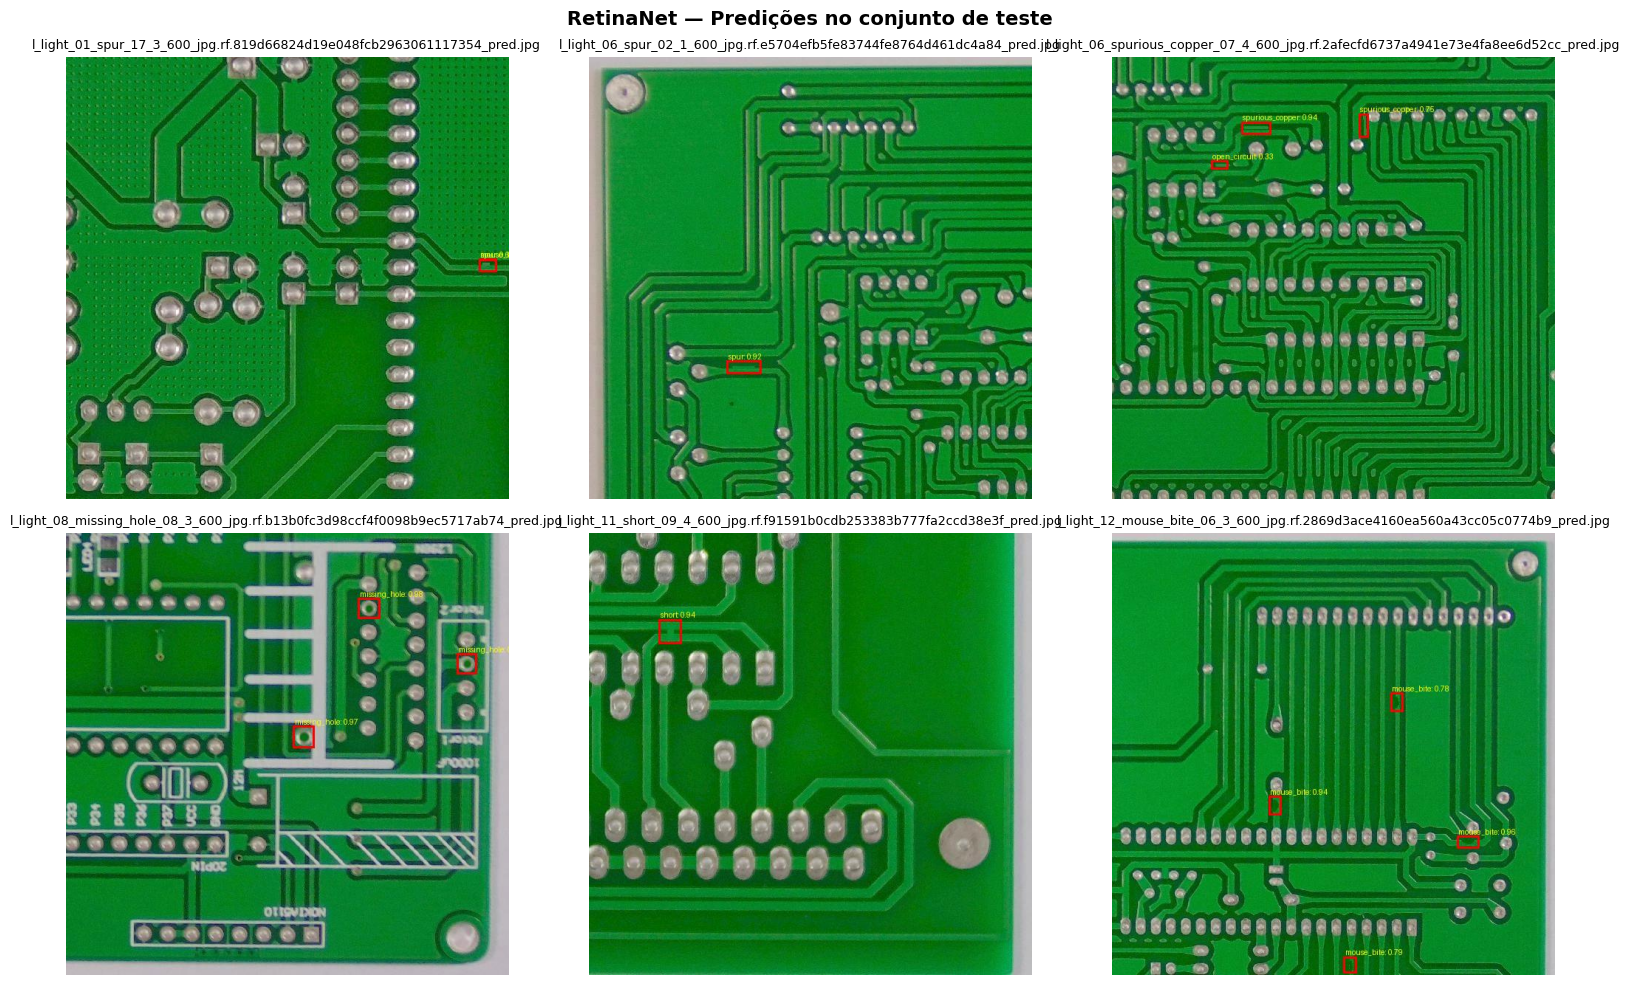

In [7]:
pred_images = sorted(out_dir.glob("*_pred.jpg"))[:6]
display_image_grid(pred_images, title="RetinaNet — Predições no conjunto de teste")